# RoBERTa PCL Detection — Augmented Oversampling

Variant of `oversampling.ipynb` that replaces some of the exact duplicates with diverse augmented paraphrases.

For each of the **794 original PCL** samples in the training split, 8 extra copies are added:
- **5 exact duplicates** of the original
- **1 synonym-replacement** paraphrase (`syn1`)
- **2 back-translation** paraphrases (`bt1`, `bt2`)

Total PCL = 794 (original) + 794 × 8 (extra) = **794 × 9 = 7,146** — identical size to `oversampling.ipynb` for a fair ablation.

In [1]:
!pip install contractions python-dotenv huggingface_hub

In [2]:
import os
import re
import random

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
)

import matplotlib.pyplot as plt
import seaborn as sns
import contractions

from dotenv import load_dotenv
from huggingface_hub import login

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    set_seed,
)

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

/home/wowthecoder/imperial-nlp-cw/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [3]:
# Local auth: load Hugging Face token from .env
load_dotenv()
hf_token = os.getenv('HF_TOKEN')
if hf_token:
    login(token=hf_token)
    print('HF token loaded from .env and login completed.')
else:
    print('HF_TOKEN not found in .env; proceeding without explicit login.')

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HF token loaded from .env and login completed.


In [4]:
# ============================================================
# Configuration
# ============================================================
MODEL_NAME    = 'roberta-base'
RUN_NAME      = 'checkpoints/augmented_oversampling'
MAX_LENGTH    = 256

ORIG_REPLICAS = 5   # exact duplicates of each original PCL sample
# Plus 1× syn1 + 1× bt1 + 1× bt2 = 3 augmented → 5+3=8 extra per sample → 9× total

DATA_ROOT      = '..'
TSV_PATH       = os.path.join(DATA_ROOT, 'dontpatronizeme_pcl.tsv')
TRAIN_IDS_PATH = os.path.join(DATA_ROOT, 'train', 'train_semeval_parids-labels.csv')
DEV_IDS_PATH   = os.path.join(DATA_ROOT, 'train', 'dev_semeval_parids-labels.csv')
AUG_TRAIN_PATH = os.path.join(DATA_ROOT, 'data_augmentation', 'augmented_train_data.csv')

os.makedirs(RUN_NAME, exist_ok=True)
print(f'RUN_NAME : {RUN_NAME}')

RUN_NAME : checkpoints/augmented_oversampling


In [5]:
def load_task1(tsv_path: str) -> pd.DataFrame:
    """Load labelled PCL dataset; binarise labels (0/1 -> 0, 2/3/4 -> 1)."""
    rows = []
    with open(tsv_path, encoding='utf-8') as f:
        for line in f.readlines()[4:]:
            parts = line.rstrip('\n').split('\t')
            if len(parts) < 6:
                continue
            orig_label = parts[-1]
            rows.append({
                'par_id':  str(parts[0]),
                'art_id':  parts[1],
                'keyword': parts[2],
                'country': parts[3],
                'text':    parts[4],
                'label':   0 if orig_label in {'0', '1'} else 1,
            })
    return pd.DataFrame(rows)

In [6]:
# ============================================================
# Load + preprocess original labelled data
# ============================================================
df = load_task1(TSV_PATH)


def preprocess_text(text: str) -> str:
    text = str(text)
    text = contractions.fix(text)
    text = re.sub(r'<[^>]+>', ' ', text)
    return text


df['clean_text'] = df['text'].apply(preprocess_text)
df['keyword']    = df['keyword'].fillna('').astype(str)
df['country']    = df['country'].fillna('').astype(str)
df['model_text'] = (
    df['keyword'].str.strip() + ' </s> '
    + df['country'].str.strip() + ' </s> '
    + df['clean_text'].str.strip()
)

print(f'Loaded dataset: {len(df):,} samples')
print(df['label'].value_counts().sort_index().rename({0: 'No-PCL', 1: 'PCL'}))

Loaded dataset: 10,469 samples
label
No-PCL    9476
PCL        993
Name: count, dtype: int64


In [7]:
# ============================================================
# Load augmented train CSV; extract syn1, bt1, bt2 entries
# ============================================================
aug_df = pd.read_csv(AUG_TRAIN_PATH, dtype={'par_id': str})

# Drop accidental duplicate header row
aug_df = aug_df[aug_df['label'].astype(str) != 'label'].copy()
aug_df['label'] = aug_df['label'].astype(int)

# Extract augmentation type from par_id suffix (e.g. '882_syn1' -> 'syn1')
aug_df['aug_type'] = aug_df['par_id'].str.extract(r'_([^_]+)$')
# Recover the original par_id so we can align with training split PCL samples
aug_df['orig_par_id'] = aug_df['par_id'].str.replace(r'_[^_]+$', '', regex=True)

print('All augmentation type counts:')
print(aug_df['aug_type'].value_counts().to_string())

# Keep only the three types we want (1 syn + 2 bt per original sample)
aug_selected = aug_df[aug_df['aug_type'].isin({'syn1', 'bt1', 'bt2'})].copy().reset_index(drop=True)

# Build model_text using pre-computed clean_text
aug_selected['clean_text'] = aug_selected['clean_text'].fillna(
    aug_selected['text'].apply(preprocess_text)
)
aug_selected['keyword']    = aug_selected['keyword'].fillna('').astype(str)
aug_selected['country']    = aug_selected['country'].fillna('').astype(str)
aug_selected['model_text'] = (
    aug_selected['keyword'].str.strip() + ' </s> '
    + aug_selected['country'].str.strip() + ' </s> '
    + aug_selected['clean_text'].str.strip()
)

print(f'\nSelected aug entries: {len(aug_selected):,}  (expected 3 × 794 = 2382)')

All augmentation type counts:
aug_type
gemini2    794
syn1       794
dup2       794
dup1       794
gemini1    794
bt1        794
bt2        794

Selected aug entries: 2,382  (expected 3 × 794 = 2382)


In [8]:
# ============================================================
# Official Train/Dev split + augmented oversampling
# ============================================================
train_ids_df = pd.read_csv(TRAIN_IDS_PATH, dtype={'par_id': str})
dev_ids_df   = pd.read_csv(DEV_IDS_PATH,   dtype={'par_id': str})

train_par_ids = set(train_ids_df['par_id'].astype(str))
dev_par_ids   = set(dev_ids_df['par_id'].astype(str))

train_df = df[df['par_id'].isin(train_par_ids)].copy().reset_index(drop=True)
dev_df   = df[df['par_id'].isin(dev_par_ids)].copy().reset_index(drop=True)

leftover_df = df[~df['par_id'].isin(train_par_ids | dev_par_ids)].copy().reset_index(drop=True)
if len(leftover_df) > 0:
    train_df = pd.concat([train_df, leftover_df], ignore_index=True)
    print(f'Appended {len(leftover_df):,} unassigned samples to training set.')


def describe_split(name: str, frame: pd.DataFrame):
    n        = len(frame)
    n_pcl    = int((frame['label'] == 1).sum())
    n_no_pcl = int((frame['label'] == 0).sum())
    ratio    = f'1:{(n_no_pcl / n_pcl):.1f}' if n_pcl > 0 else 'undefined'
    print(f'{name:<32} -> total={n:,} | PCL={n_pcl:,} | No-PCL={n_no_pcl:,} | ratio={ratio}')


describe_split('Train (before oversampling)', train_df)
describe_split('Dev', dev_df)

# ── Build the 8 extra copies per original PCL sample ──────────────────────────
train_pcl = train_df[train_df['label'] == 1]

# 5 exact duplicates of each original PCL sample
dup_pcl = pd.concat([train_pcl] * ORIG_REPLICAS, ignore_index=True)

# Augmented entries that correspond to training-split PCL par_ids only
aug_cols = ['par_id', 'keyword', 'country', 'text', 'clean_text', 'model_text', 'label']
aug_train_selected = aug_selected[
    aug_selected['orig_par_id'].isin(train_par_ids)
][aug_cols].reset_index(drop=True)

# Concatenate: original train + 5 duplicates + syn1 + bt1 + bt2
train_df = pd.concat([train_df, dup_pcl, aug_train_selected], ignore_index=True)
train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

describe_split('Train (after oversampling)', train_df)
print(f'\nExpected total PCL: 794 × 9 = {794 * 9:,}')

Train (before oversampling)      -> total=8,375 | PCL=794 | No-PCL=7,581 | ratio=1:9.5
Dev                              -> total=2,094 | PCL=199 | No-PCL=1,895 | ratio=1:9.5
Train (after oversampling)       -> total=14,727 | PCL=7,146 | No-PCL=7,581 | ratio=1:1.1

Expected total PCL: 794 × 9 = 7,146


In [9]:
# ============================================================
# Tokenization + Hugging Face Datasets
# ============================================================
train_hf = Dataset.from_pandas(
    train_df[['model_text', 'label']].rename(columns={'model_text': 'text'}),
    preserve_index=False,
)
dev_hf = Dataset.from_pandas(
    dev_df[['model_text', 'label']].rename(columns={'model_text': 'text'}),
    preserve_index=False,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)


train_ds = train_hf.map(tokenize, batched=True, remove_columns=['text'])
dev_ds   = dev_hf.map(tokenize,   batched=True, remove_columns=['text'])

train_ds = train_ds.rename_column('label', 'labels')
dev_ds   = dev_ds.rename_column('label', 'labels')

train_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
dev_ds.set_format(type='torch',   columns=['input_ids', 'attention_mask', 'labels'])

print(train_ds)
print(dev_ds)

Map: 100%|██████████| 2094/2094 [00:00<00:00, 31326.34 examples/s]

Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 14727
})
Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 2094
})


In [10]:
# ============================================================
# Metrics (PCL F1 focused, matching oversampling.ipynb)
# ============================================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'f1_pcl':        f1_score(labels, preds, average='binary', pos_label=1, zero_division=0),
        'precision_pcl': precision_score(labels, preds, average='binary', pos_label=1, zero_division=0),
        'recall_pcl':    recall_score(labels, preds, average='binary', pos_label=1, zero_division=0),
        'f1_macro':      f1_score(labels, preds, average='macro', zero_division=0),
    }

In [11]:
# ============================================================
# Model + TrainingArguments + Trainer
# ============================================================
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

training_args = TrainingArguments(
    RUN_NAME,
    num_train_epochs=2,
    save_total_limit=2,
    learning_rate=1e-5,
    eval_strategy='steps',
    eval_steps=500,
    save_strategy='steps',
    save_steps=500,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    metric_for_best_model='f1_pcl',
    greater_is_better=True,
    load_best_model_at_end=True,
    warmup_steps=400,
    eval_delay=1000,
    report_to='none',
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=dev_ds,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5, early_stopping_threshold=0.001)],
)

print('Trainer configured.')

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 536.92it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Trainer configured.


In [12]:
train_result = trainer.train()
train_result

Step,Training Loss,Validation Loss,F1 Pcl,Precision Pcl,Recall Pcl,F1 Macro
1000,0.590323,0.496627,0.478049,0.353365,0.738693,0.694104
1500,0.514975,0.492129,0.538053,0.415301,0.763819,0.733007
2000,0.400362,0.435890,0.553911,0.478102,0.658291,0.748557
2500,0.412625,0.471962,0.569343,0.446991,0.783920,0.752254
3000,0.346578,0.444850,0.604752,0.530303,0.703518,0.777812
3500,0.296396,0.499144,0.596273,0.507042,0.723618,0.771821
4000,0.203143,0.585163,0.587269,0.496528,0.718593,0.766480
4500,0.165663,0.506573,0.581818,0.602151,0.562814,0.769742
5000,0.137582,0.601769,0.594714,0.529412,0.678392,0.772718
5500,0.129625,0.624684,0.602510,0.516129,0.723618,0.775649


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.54s/it]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

TrainOutput(global_step=5500, training_loss=0.3461616529984908, metrics={'train_runtime': 486.4836, 'train_samples_per_second': 60.545, 'train_steps_per_second': 15.137, 'total_flos': 1115206999807740.0, 'train_loss': 0.3461616529984908, 'epoch': 1.4937533948940793})

In [13]:
eval_metrics = trainer.evaluate()
print('Evaluation metrics:')
for k, v in eval_metrics.items():
    if isinstance(v, (int, float)):
        print(f'  {k}: {v:.4f}')
    else:
        print(f'  {k}: {v}')

Evaluation metrics:
  eval_loss: 0.4457
  eval_f1_pcl: 0.6078
  eval_precision_pcl: 0.5321
  eval_recall_pcl: 0.7085
  eval_f1_macro: 0.7794
  eval_runtime: 9.0996
  eval_samples_per_second: 230.1200
  eval_steps_per_second: 57.5850
  epoch: 1.4938


              precision    recall  f1-score   support

      No-PCL     0.9683    0.9346    0.9511      1895
         PCL     0.5321    0.7085    0.6078       199

    accuracy                         0.9131      2094
   macro avg     0.7502    0.8216    0.7794      2094
weighted avg     0.9268    0.9131    0.9185      2094



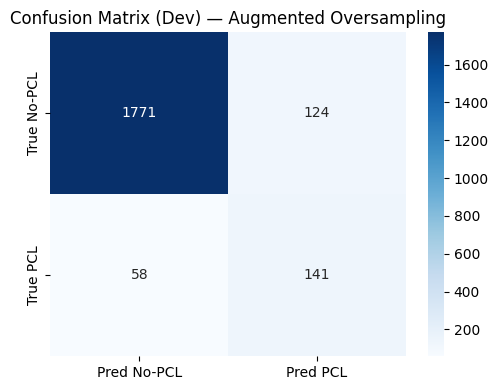

In [14]:
# ============================================================
# Detailed evaluation report
# ============================================================
pred_output = trainer.predict(dev_ds)
logits = pred_output.predictions
y_true = pred_output.label_ids
y_pred = np.argmax(logits, axis=-1)

print(classification_report(y_true, y_pred, target_names=['No-PCL', 'PCL'], digits=4, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pred No-PCL', 'Pred PCL'],
    yticklabels=['True No-PCL', 'True PCL'],
)
plt.title('Confusion Matrix (Dev) — Augmented Oversampling')
plt.tight_layout()
plt.savefig(os.path.join(RUN_NAME, 'confusion_matrix.png'), dpi=150)
plt.show()

In [15]:
BEST_MODEL_DIR = os.path.join(RUN_NAME, 'best')
trainer.save_model(BEST_MODEL_DIR)
tokenizer.save_pretrained(BEST_MODEL_DIR)
print(f'Saved best model and tokenizer to: {BEST_MODEL_DIR}')

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.64s/it]

Saved best model and tokenizer to: checkpoints/augmented_oversampling/best
